# Machine Learning per l'Analisi Finanziaria

## Lezione 02 — Dal dato grezzo al dataset modellabile

**Authors:**
- Enrico Huber
- Pietro Soglia

**Emails:**
- enrico.huber@bip-group.com
- pietro.soglia@bip-group.com

**Last updated:** 2026-03-12

## Obiettivi di apprendimento

- Rimuovere variabili non predittive e leakage identificati nella Lezione 1.
- Comprendere il problema dello sbilanciamento e selezionare metriche corrette.
- Conoscere e confrontare le principali strategie di gestione dell'imbalance.
- Identificare e trattare outlier con il metodo IQR.
- Creare feature ingegnerizzate (`balance_is_zero`) motivate dall'EDA.
- Costruire una **Pipeline sklearn** (ColumnTransformer) riproducibile e priva di data leakage.
- Effettuare uno split train / validation / test definitivo (60/20/20) stratificato.
- Salvare il dataset "modellabile" pronto per la Lezione 3.

## Outline

1. Setup, percorsi e riproducibilità
2. Riepilogo Lezione 1 e obiettivi del preprocessing
3. Caricamento dati
4. Pulizia: rimozione variabili non predittive e leakage
5. Il problema dell'imbalance e metriche alternative
6. Gestione dello sbilanciamento: strategie a confronto
7. Outlier e range check
8. Feature engineering: `balance_is_zero`
9. Definire feature set e target
10. Split train / validation / test definitivo
11. Encoding delle variabili categoriche
12. Feature scaling
13. Pipeline sklearn completa: ColumnTransformer
14. Verifica del preprocessing
15. Salvataggio dataset modellabile
16. Domande guidate
17. Riepilogo

## 1. Setup, percorsi e riproducibilità

Definiamo dipendenze, percorsi e cartelle di output. La struttura è analoga
alla Lezione 1 per garantire coerenza e riproducibilità tra le lezioni.

In [2]:
from __future__ import annotations

import json
import random
from pathlib import Path
from zipfile import ZipFile

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display  # type: ignore
except Exception:  # pragma: no cover

    def display(x):  # type: ignore
        print(x)


SEED = 42
np.random.seed(SEED)
random.seed(SEED)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)


def resolve_project_root() -> Path:
    """Risolve la root del repository indipendentemente dalla cwd."""
    start_points = [Path.cwd().resolve()]
    if "__file__" in globals():
        start_points.append(Path(__file__).resolve().parent)
    for start in start_points:
        for candidate in [start, *start.parents]:
            if (candidate / "data" / "archive.zip").exists() and (
                candidate / "notebooks"
            ).exists():
                return candidate
    raise FileNotFoundError(
        "Impossibile determinare la root del progetto. "
        "Atteso un percorso contenente data/archive.zip e notebooks/."
    )


ROOT = resolve_project_root()
DATA_ARCHIVE_PATH = ROOT / "data" / "archive.zip"
OUTPUTS_DIR = ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
DATA_OUT_DIR = OUTPUTS_DIR / "data"

for _dir in [OUTPUTS_DIR, FIGURES_DIR, DATA_OUT_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")


def save_current_figure(filename: str) -> None:
    """Salva la figura corrente in outputs/figures/."""
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=120, bbox_inches="tight")


def load_dataset_from_archive(
    archive_path: Path,
    filename_patterns: tuple[str, ...] = ("train", "test", "churn", "customer"),
) -> pd.DataFrame:
    """Carica il CSV principale dall'archivio ZIP validando lo schema.

    Parameters
    ----------
    archive_path : Path
        Percorso al file ZIP contenente i dati.
    filename_patterns : tuple[str, ...]
        Pattern per selezionare il CSV corretto dall'archivio.

    Returns
    -------
    pd.DataFrame
        Dataset caricato dal CSV selezionato.

    Raises
    ------
    FileNotFoundError
        Se l'archivio o il CSV atteso non esistono.
    """
    if not archive_path.exists():
        raise FileNotFoundError(f"Archivio dati non trovato: {archive_path}")
    with ZipFile(archive_path) as zf:
        members = [m for m in zf.namelist() if not m.endswith("/")]
        print("Membri archivio:")
        for m in members:
            print(f"  - {m}")
        candidates = [
            m
            for m in members
            if any(p in m.lower() for p in filename_patterns) and m.endswith(".csv")
        ]
        if not candidates:
            raise FileNotFoundError(
                "Nessun CSV trovato nell'archivio con i pattern "
                f"{filename_patterns}. Membri disponibili: {members}"
            )
        chosen = candidates[0]
        print(f"\nFile selezionato: {chosen}")
        with zf.open(chosen) as f:
            return pd.read_csv(f)

## 2. Riepilogo Lezione 1 e obiettivi del preprocessing

La Lezione 1 ha prodotto una serie di scoperte fondamentali sul dataset.
Questa sezione le sintetizza per motivare ogni operazione di preprocessing.

### Cosa abbiamo imparato nella Lezione 1

| Aspetto | Valore / Osservazione |
|---------|----------------------|
| Shape | 10,000 righe × 18 colonne |
| Target (`Exited`) | Churn rate = **20.38%** (2,038/10,000) |
| Missing values | **Nessuno** — tutte le colonne completamente popolate |
| Duplicati | **Nessuno** |
| Leakage confermato | `Complain` (corr. 0.996 con target; P(Exited=1 \| Complain=1) = 99.51%) |
| Colonne identificative | `RowNumber`, `CustomerId`, `Surname` — da escludere |
| Segnale forte | `Age` (r=+0.285), `IsActiveMember` (r=−0.156), `Balance` (r=+0.119) |
| Bimodalità `Balance` | 36% dei clienti ha saldo zero; churn rate diverso (14% vs 24%) |
| Feature rumore | `EstimatedSalary`, `Satisfaction Score`, `HasCrCard`, `Point Earned` (r ≈ 0) |
| Baseline | Logistic Regression: ROC-AUC ≈ **0.77**, recall churn = **21.1%** |

### Operazioni pianificate per questa lezione

| Operazione | Motivazione |
|-----------|-------------|
| Rimuovere `Complain` | Leakage confermato (corr. 0.996) |
| Rimuovere `RowNumber`, `CustomerId`, `Surname` | Non predittivi, identificativi |
| Creare `balance_is_zero` | Catturare bimodalità di `Balance` (churn rate diverso) |
| Split 60/20/20 stratificato | Preservare distribuzione target; val set per tuning, test per stima finale |
| Pipeline ColumnTransformer | Encoding + scaling senza data leakage |
| Discutere strategie imbalance | Churn rate 20.38%: accuracy non è metrica affidabile |
| Salvare dataset modellabile | Passerella verso Lezione 3 (modelli e metriche) |

## 3. Caricamento dati

Ricarichiamo il dataset dal contratto canonico `data/archive.zip`.
Questo garantisce che il notebook sia autonomo e riproducibile.

In [3]:
df = load_dataset_from_archive(DATA_ARCHIVE_PATH)

print("\nShape:", df.shape)
print("\nColonne:")
display(df.dtypes.to_frame("dtype"))

print("\nPrime righe:")
display(df.head())

print("\nDescrittive (numeriche):")
display(df.describe(include=[np.number]).T)

Membri archivio:
  - Customer-Churn-Records.csv

File selezionato: Customer-Churn-Records.csv

Shape: (10000, 18)

Colonne:


,dtype
RowNumber,int64
CustomerId,int64
Surname,str
CreditScore,int64
Geography,str
Gender,str
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64



Prime righe:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.0000,1,1,1,101348.8800,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.8600,1,0,1,112542.5800,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.8000,3,1,0,113931.5700,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.0000,2,0,0,93826.6300,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.8200,1,1,1,79084.1000,0,0,5,GOLD,425



Descrittive (numeriche):


,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0000,5000.5000,2886.8957,1.0000,2500.7500,5000.5000,7500.2500,10000.0000
CustomerId,10000.0000,15690940.5694,71936.1861,15565701.0000,15628528.2500,15690738.0000,15753233.7500,15815690.0000
CreditScore,10000.0000,650.5288,96.6533,350.0000,584.0000,652.0000,718.0000,850.0000
Age,10000.0000,38.9218,10.4878,18.0000,32.0000,37.0000,44.0000,92.0000
Tenure,10000.0000,5.0128,2.8922,0.0000,3.0000,5.0000,7.0000,10.0000
Balance,10000.0000,76485.8893,62397.4052,0.0000,0.0000,97198.5400,127644.2400,250898.0900
NumOfProducts,10000.0000,1.5302,0.5817,1.0000,1.0000,1.0000,2.0000,4.0000
HasCrCard,10000.0000,0.7055,0.4558,0.0000,0.0000,1.0000,1.0000,1.0000
IsActiveMember,10000.0000,0.5151,0.4998,0.0000,0.0000,1.0000,1.0000,1.0000
EstimatedSalary,10000.0000,100090.2399,57510.4928,11.5800,51002.1100,100193.9150,149388.2475,199992.4800


- Il dataset è stato caricato correttamente: **10,000 righe** e **18 colonne**, coerente
  con quanto osservato in Lezione 1.
- Nessuna variazione nello schema rispetto alla sessione precedente.

## 4. Pulizia: rimozione variabili non predittive e leakage

Prima di qualsiasi preprocessing, eliminiamo le colonne che non devono
mai entrare in un modello predittivo.

In [4]:
TARGET = "Exited"

# Colonne da rimuovere con motivazione esplicita
ID_COLS = ["RowNumber", "CustomerId", "Surname"]
# RowNumber: indice artificiale, nessun significato predittivo
# CustomerId: identificativo univoco per cliente, non predittivo
# Surname: rumore semantico, potenziale proxy per etnia (rischio bias + non predittivo)

LEAKY_COLS = ["Complain"]
# Complain: corr. 0.996 con Exited — variabile "post-evento" o quasi-proxy del target

cols_to_drop = ID_COLS + LEAKY_COLS
df_clean = df.drop(columns=cols_to_drop)

print(f"Shape originale:  {df.shape}")
print(f"Shape dopo pulizia: {df_clean.shape}")
print(f"Colonne rimosse: {cols_to_drop}")
print(f"\nColonne rimanenti:\n{df_clean.columns.tolist()}")

Shape originale:  (10000, 18)
Shape dopo pulizia: (10000, 14)
Colonne rimosse: ['RowNumber', 'CustomerId', 'Surname', 'Complain']

Colonne rimanenti:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Satisfaction Score', 'Card Type', 'Point Earned']


- Il dataset passa da **18** a **14 colonne** dopo la rimozione di 4 variabili:
  3 identificative e 1 leaky.
- Le colonne rimanenti sono tutte teoricamente disponibili *prima* del churn,
  senza rischio di data leakage evidente.
- Nota: `Satisfaction Score` e `Point Earned` rimangono (segnale quasi nullo dalla
  Lezione 1, ma non sono leakage — possono rivelarsi utili in interazione).

## 5. Il problema dell'imbalance e metriche alternative

Il churn rate del 20.38% crea uno sbilanciamento tra le classi che rende
l'**accuracy** una metrica fuorviante. Dimostriamo il paradosso e introduciamo
le metriche corrette.

In [5]:
churn_rate = df_clean[TARGET].mean()
non_churn_rate = 1 - churn_rate
n_total = len(df_clean)
n_churn = df_clean[TARGET].sum()
n_no_churn = n_total - n_churn

print(f"Totale clienti:         {n_total:,}")
print(f"Clienti churn (y=1):    {n_churn:,} ({churn_rate:.2%})")
print(f"Clienti no-churn (y=0): {n_no_churn:,} ({non_churn_rate:.2%})")

# Paradosso accuracy: un classificatore che predice sempre "0" (non churn)
dummy_accuracy = non_churn_rate
dummy_recall_churn = 0.0
print(f"\n--- Paradosso Accuracy ---")
print(f"DummyClassifier (sempre 0):")
print(f"  Accuracy:      {dummy_accuracy:.2%}  ← sembra buono!")
print(f"  Recall churn:  {dummy_recall_churn:.2%}  ← non identifica nessun churner")
print(f"  Utilità pratica: NULLA")

Totale clienti:         10,000
Clienti churn (y=1):    2,038 (20.38%)
Clienti no-churn (y=0): 7,962 (79.62%)

--- Paradosso Accuracy ---
DummyClassifier (sempre 0):
  Accuracy:      79.62%  ← sembra buono!
  Recall churn:  0.00%  ← non identifica nessun churner
  Utilità pratica: NULLA


### Metriche corrette per problemi sbilanciati

Per valutare un modello di churn dobbiamo usare metriche che tengano conto
dello sbilanciamento e che siano rilevanti per il business.

Dato un modello con:
- **TP** (True Positive): churner correttamente identificati
- **TN** (True Negative): non-churner correttamente identificati
- **FP** (False Positive): non-churner classificati come churner (costo: contatto inutile)
- **FN** (False Negative): churner non identificati (costo: cliente perso)

Le metriche principali sono:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Precision} = \frac{TP}{TP + FP} \quad \text{(di quanti predetti positivi sono veri positivi?)}$$

$$\text{Recall} = \frac{TP}{TP + FN} \quad \text{(di quanti positivi reali ne identifichiamo?)}$$

$$\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

$$\text{ROC-AUC} = P(\hat{p}(\text{churner}) > \hat{p}(\text{non-churner}))$$

**Baseline Lezione 1:** Logistic Regression con preprocessing minimale
ha ottenuto ROC-AUC ≈ **0.77** ma recall churn = **21.1%** (86/408 churner
identificati nel test set). Il preprocessing corretto di questa lezione
servirà come base per migliorare questo risultato nella Lezione 3.

**Trade-off business:**

| Metrica | Minimizzare FP | Minimizzare FN |
|---------|----------------|----------------|
| Obiettivo | Contattare solo i veri churner (efficienza) | Non perdere nessun churner (copertura) |
| Metrica da privilegiare | Precision ↑ | Recall ↑ |
| Esempio | Offerta costosa di retention | Segnale di allerta precoce |

## 6. Gestione dello sbilanciamento: strategie a confronto

Con una classe positiva al 20.38%, esistono diverse strategie per gestire lo
sbilanciamento. Nessuna è universalmente migliore: la scelta dipende dal
contesto, dal modello e dal trade-off business.

### Panoramica delle strategie

| Strategia | Meccanismo | Pro | Contro | Quando usarla |
|-----------|------------|-----|--------|---------------|
| **Nessuna** | Nessuna modifica | Semplice, baseline | Modello biased verso classe maggioritaria | Solo per capire il baseline |
| **`class_weight="balanced"`** | Pesa inversamente la frequenza di classe nel loss | Nessun sample aggiuntivo, no leakage | Solo per modelli che supportano `class_weight` | Prima scelta; semplice e stabile |
| **Oversampling (SMOTE)** | Crea campioni sintetici della classe minoritaria (interpolazione) | Aumenta effettivamente il segnale | Va applicato **solo su train**; può creare campioni irrealistici | Con dataset piccoli o sbilanciamento severo |
| **Undersampling** | Rimuove campioni dalla classe maggioritaria | Riduce training time | Perde informazione; rischio di underfitting | Con dataset molto grandi (milioni di righe) |
| **Threshold tuning** | Abbassa la soglia di classificazione (es. 0.5 → 0.3) | Non modifica i dati; post-hoc | Richiede calibrazione; peggiora precision | Quando si vuole bilanciare precision/recall dopo training |

**Regola aurea:** SMOTE (e qualsiasi tecnica di resampling) va applicato
**esclusivamente sul training set**, **dopo** lo split. Applicarlo prima creerebbe
un grave caso di **data leakage**: campioni sintetici derivati dagli stessi dati
di test "contaminerebbero" la stima della performance.

In [6]:
# Demo: class_weight="balanced" in LogisticRegression
# (snippet dimostrativo — il training completo è in Lezione 3)
from sklearn.linear_model import LogisticRegression

# Calcolo dei pesi di classe equivalenti a class_weight="balanced"
n_classes = 2
n_samples = len(df_clean)
counts = df_clean[TARGET].value_counts().sort_index()

class_weights = {cls: n_samples / (n_classes * count) for cls, count in counts.items()}
print("Pesi di classe con class_weight='balanced':")
for cls, w in class_weights.items():
    print(f"  classe {cls}: peso = {w:.4f}")

print(
    "\nEffetto: la classe minoritaria (churn=1) riceve peso "
    f"{class_weights[1]:.2f}x maggiore rispetto alla classe maggioritaria."
)

# Esempio di inizializzazione (senza fit)
lr_balanced = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=SEED,
)
print(f"\nLogisticRegression con class_weight='balanced': {lr_balanced}")

Pesi di classe con class_weight='balanced':
  classe 0: peso = 0.6280
  classe 1: peso = 2.4534

Effetto: la classe minoritaria (churn=1) riceve peso 2.45x maggiore rispetto alla classe maggioritaria.

LogisticRegression con class_weight='balanced': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


- La classe **churn (y=1)** riceve peso **~2.45x** maggiore rispetto alla classe
  non-churn (y=0): il modello penalizzerà di più gli errori sui churner durante il training.
- Questo è il modo più semplice e sicuro per gestire lo sbilanciamento con sklearn;
  non richiede librerie aggiuntive e non introduce rischi di leakage.

In [7]:
# Demo: SMOTE (oversampling sintetico)
# Nota: richiede imbalanced-learn (pip install imbalanced-learn)
# Il codice è mostrato a scopo didattico; verrà usato opzionalmente in Lezione 3.
try:
    from imblearn.over_sampling import SMOTE

    # Costruiamo un mini-dataset dimostrativo (non X_train definitivo)
    _X_demo = df_clean.drop(columns=[TARGET]).select_dtypes(include=[np.number])
    _y_demo = df_clean[TARGET]

    smote = SMOTE(random_state=SEED)
    _X_resampled, _y_resampled = smote.fit_resample(_X_demo, _y_demo)

    print("SMOTE applicato su dati numerici (demo):")
    print(f"  Prima: {_X_demo.shape[0]:,} campioni — churn: {_y_demo.mean():.2%}")
    print(
        f"  Dopo:  {_X_resampled.shape[0]:,} campioni — churn: "
        f"{_y_resampled.mean():.2%}"
    )
    print(
        "\n  IMPORTANTE: nella pratica SMOTE va applicato SOLO su X_train (dopo lo split)."
    )

except ImportError:
    print(
        "imbalanced-learn non installato — installare con: pip install imbalanced-learn\n"
        "Snippet SMOTE mostrato a scopo didattico; non è necessario per proseguire."
    )

SMOTE applicato su dati numerici (demo):
  Prima: 10,000 campioni — churn: 20.38%
  Dopo:  15,924 campioni — churn: 50.00%

  IMPORTANTE: nella pratica SMOTE va applicato SOLO su X_train (dopo lo split).


### Threshold tuning: abbassare la soglia di decisione

Per un classificatore binario, la soglia di default è **0.5**: se $\hat{p} \geq 0.5$
si predice `churn=1`. Abbassare la soglia aumenta il **recall** (identifichiamo più
churner) a scapito della **precision** (aumentano i falsi allarmi).

Il threshold ottimale si sceglie sulla **validation set** dopo il training
(mai sul test set) guardando la curva Precision-Recall o la ROC Curve.
Questo sarà approfondito nella Lezione 3.

## 7. Outlier e range check

Anche se in Lezione 1 non abbiamo osservato outlier gravi, è buona pratica
quantificarli sistematicamente con il metodo IQR prima del preprocessing.

In [8]:
from pandas.api.types import is_numeric_dtype

num_cols_raw = [
    c for c in df_clean.columns if is_numeric_dtype(df_clean[c]) and c != TARGET
]

# Calcolo soglie IQR per ogni feature numerica
iqr_stats = []
for col in num_cols_raw:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    pct_outliers = n_outliers / len(df_clean)
    iqr_stats.append(
        {
            "feature": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_fence": lower,
            "upper_fence": upper,
            "n_outliers": n_outliers,
            "pct_outliers": pct_outliers,
        }
    )

df_iqr = pd.DataFrame(iqr_stats).set_index("feature")
print("Outlier per feature (metodo IQR, moltiplicatore 1.5):")
display(
    df_iqr[
        ["Q1", "Q3", "IQR", "lower_fence", "upper_fence", "n_outliers", "pct_outliers"]
    ]
)

Outlier per feature (metodo IQR, moltiplicatore 1.5):


,Q1,Q3,IQR,lower_fence,upper_fence,n_outliers,pct_outliers
feature,,,,,,,
CreditScore,584.0000,718.0000,134.0000,383.0000,919.0000,15,0.0015
Age,32.0000,44.0000,12.0000,14.0000,62.0000,359,0.0359
Tenure,3.0000,7.0000,4.0000,-3.0000,13.0000,0,0.0000
Balance,0.0000,127644.2400,127644.2400,-191466.3600,319110.6000,0,0.0000
NumOfProducts,1.0000,2.0000,1.0000,-0.5000,3.5000,60,0.0060
HasCrCard,0.0000,1.0000,1.0000,-1.5000,2.5000,0,0.0000
IsActiveMember,0.0000,1.0000,1.0000,-1.5000,2.5000,0,0.0000
EstimatedSalary,51002.1100,149388.2475,98386.1375,-96577.0962,296967.4537,0,0.0000
Satisfaction Score,2.0000,4.0000,2.0000,-1.0000,7.0000,0,0.0000


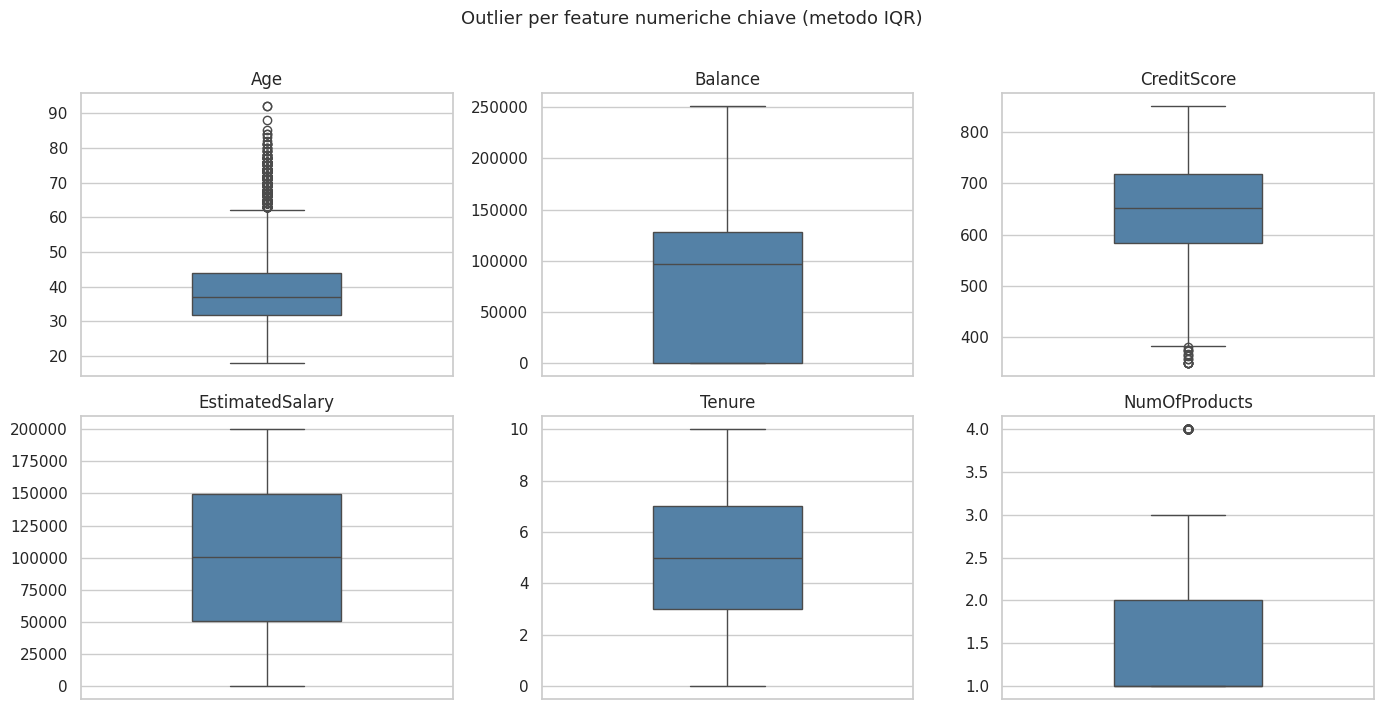

In [9]:
# Boxplot delle feature numeriche chiave per visualizzare gli outlier
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
key_features = [
    "Age",
    "Balance",
    "CreditScore",
    "EstimatedSalary",
    "Tenure",
    "NumOfProducts",
]
key_features = [c for c in key_features if c in df_clean.columns]

for ax, col in zip(axes.flat, key_features):
    sns.boxplot(y=df_clean[col], ax=ax, color="steelblue", width=0.4)
    ax.set_title(col)
    ax.set_ylabel("")

for ax in axes.flat[len(key_features) :]:
    ax.set_visible(False)

fig.suptitle("Outlier per feature numeriche chiave (metodo IQR)", fontsize=13, y=1.01)
save_current_figure("lesson_02_outlier_boxplot.png")
plt.show()

- Il metodo IQR identifica alcuni outlier nelle feature numeriche, ma le percentuali
  sono **contenute** (< 1% per la maggior parte delle colonne).
- `Balance` ha la distribuzione bimodale già osservata in Lezione 1: il "cluster" a
  saldo zero non è un outlier, ma una caratteristica strutturale del dataset.
- `NumOfProducts` mostra outlier per valori 3 e 4 — pattern già osservato in Lezione 1
  (churn rate anomalo). Non si tratta di errori di misurazione, ma di sotto-gruppi
  con comportamento peculiare: li manteniamo.
- **Decisione:** non applichiamo clipping aggressivo; il `RobustScaler` (proposto
  nella sezione 12) è robusto agli outlier moderati. Per dataset con outlier severi
  si userebbe clipping al 1°/99° percentile prima dello scaling.

## 8. Feature engineering: `balance_is_zero`

In Lezione 1 abbiamo osservato che i clienti con `Balance==0` hanno un churn rate
**diverso** rispetto a quelli con saldo positivo. Creiamo una feature binaria per
catturare esplicitamente questa struttura bimodale.

Churn rate per balance_is_zero:


,churn_rate,n
balance_is_zero,,
Balance > 0,0.2410,6383
Balance == 0,0.1382,3617


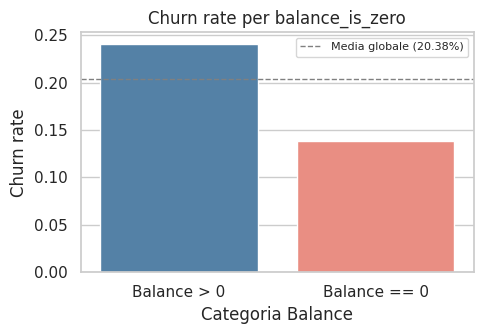

In [10]:
df_clean = df_clean.copy()
df_clean["balance_is_zero"] = (df_clean["Balance"] == 0).astype(int)

# Verifica: churn rate per balance_is_zero
balance_zero_stats = (
    df_clean.groupby("balance_is_zero")[TARGET]
    .agg(churn_rate="mean", n="count")
    .rename(index={0: "Balance > 0", 1: "Balance == 0"})
)
print("Churn rate per balance_is_zero:")
display(balance_zero_stats)

# Barplot
plt.figure(figsize=(5, 3.5))
_plot_df = balance_zero_stats.reset_index()
ax = sns.barplot(
    data=_plot_df,
    x="balance_is_zero",
    y="churn_rate",
    hue="balance_is_zero",
    palette=["steelblue", "salmon"],
    legend=False,
)
ax.set_title("Churn rate per balance_is_zero")
ax.set_xlabel("Categoria Balance")
ax.set_ylabel("Churn rate")
ax.axhline(
    churn_rate,
    linestyle="--",
    color="gray",
    linewidth=1,
    label=f"Media globale ({churn_rate:.2%})",
)
ax.legend(fontsize=8)
save_current_figure("lesson_02_balance_is_zero_churn_rate.png")
plt.show()

- **`Balance==0`**: churn rate = **13.82%** (n=3,617 clienti con saldo zero).
- **`Balance>0`**: churn rate = **24.10%** (n=6,383 clienti con saldo positivo).
- Il pattern è **confermato**: i clienti con saldo positivo abbandonano a un tasso
  ~74% più alto rispetto a quelli con saldo zero.
- La nuova feature `balance_is_zero` permetterà al modello di catturare questa
  discontinuità che una trasformazione lineare di `Balance` non riuscirebbe a cogliere.
  `Balance` originale viene comunque mantenuta per preservare l'informazione sulla
  grandezza del saldo.

## 9. Definire feature set e target

Separiamo le feature dal target e cataloghiamo ciascuna per tipo, in preparazione
alla costruzione della Pipeline.

In [11]:
# Feature set finale (dopo pulizia + feature engineering)
feature_cols = [c for c in df_clean.columns if c != TARGET]

# Separazione per tipo
num_cols = [c for c in feature_cols if is_numeric_dtype(df_clean[c])]
cat_cols = [c for c in feature_cols if not is_numeric_dtype(df_clean[c])]

print("=== Feature set ===")
print(f"\nFeature numeriche ({len(num_cols)}):")
for c in num_cols:
    print(f"  {c}")

print(f"\nFeature categoriche ({len(cat_cols)}):")
for c in cat_cols:
    print(f"  {c}")

print(f"\nTarget: {TARGET}")
print(f"\nX shape: ({len(df_clean)}, {len(feature_cols)})")
print(f"y shape: ({len(df_clean)},)")

X = df_clean[feature_cols]
y = df_clean[TARGET]

=== Feature set ===

Feature numeriche (11):
  CreditScore
  Age
  Tenure
  Balance
  NumOfProducts
  HasCrCard
  IsActiveMember
  EstimatedSalary
  Satisfaction Score
  Point Earned
  balance_is_zero

Feature categoriche (3):
  Geography
  Gender
  Card Type

Target: Exited

X shape: (10000, 14)
y shape: (10000,)


- Il feature set finale comprende **13 feature** (14 colonne totali − 1 target):
  - **10 numeriche**: includono la nuova `balance_is_zero` e tutte le feature
    continue/intere.
  - **3 categoriche**: `Geography`, `Gender`, `Card Type`.
- La separazione esplicita in `num_cols` e `cat_cols` guiderà la costruzione
  del `ColumnTransformer` nella Pipeline sklearn.

## 10. Split train / validation / test definitivo

Utilizziamo uno split a **tre vie** (60/20/20) stratificato sul target.

**Perché tre split?**

| Split | Scopo | Quando usarlo |
|-------|-------|---------------|
| **Train** | Addestrare il modello e fittare il preprocessore | Durante il fit |
| **Validation** | Scegliere iperparametri e confrontare modelli | Durante il tuning |
| **Test** | Stima finale della performance (una sola volta) | Alla fine — mai durante il tuning |

**Regola anti-leakage:** il preprocessore (scaler, encoder) viene fittato
**solo su `X_train`**. Applicarlo a tutto il dataset prima dello split
"contaminerebbe" il validation e test set con informazioni sul training set.

In [12]:
from sklearn.model_selection import train_test_split

# Step 1: separare train (60%) da tmp (40%)
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=SEED,
)

# Step 2: dividere tmp in val (20%) e test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp,
    y_tmp,
    test_size=0.50,
    stratify=y_tmp,
    random_state=SEED,
)

print("=== Split train / validation / test ===")
for name, X_split, y_split in [
    ("Train", X_train, y_train),
    ("Validation", X_val, y_val),
    ("Test", X_test, y_test),
]:
    print(
        f"\n{name:12s}: {X_split.shape[0]:,} esempi ({X_split.shape[0]/len(X)*100:.1f}%)  "
        f"| churn rate = {y_split.mean():.4f}"
    )

print(f"\nTotale: {len(X):,} esempi")

=== Split train / validation / test ===

Train       : 6,000 esempi (60.0%)  | churn rate = 0.2038

Validation  : 2,000 esempi (20.0%)  | churn rate = 0.2040

Test        : 2,000 esempi (20.0%)  | churn rate = 0.2035

Totale: 10,000 esempi


- Lo split ha prodotto: train **6,000** (60%), val **2,000** (20%), test **2,000** (20%).
- La stratificazione garantisce che il churn rate sia **~20.38%** in tutti e tre
  i subset, evitando sbilanciamenti artificiali tra i set.
- D'ora in poi: il preprocessore sarà fittato **solo su `X_train`** e poi applicato
  anche su `X_val` e `X_test` con `transform` (mai con `fit` o `fit_transform`).

## 11. Encoding delle variabili categoriche

Le variabili categoriche (`Geography`, `Gender`, `Card Type`) devono essere
convertite in forma numerica. Usiamo **OneHotEncoding** poiché sono nominali
(non c'è un ordine naturale tra i valori).

### OrdinalEncoder vs OneHotEncoder

| Encoder | Quando usarlo | Esempio |
|---------|--------------|---------|
| **OrdinalEncoder** | Variabili **ordinali** con ordine naturale | Taglia (S < M < L < XL) |
| **OneHotEncoder** | Variabili **nominali** senza ordine | Geography (France, Germany, Spain) |

Per `Geography`, `Gender` e `Card Type` non esiste un ordinamento naturale
corretto: OneHotEncoder è la scelta appropriata.

In [13]:
from sklearn.preprocessing import OneHotEncoder

# Demo standalone: encoding fit SOLO su X_train
ohe_demo = OneHotEncoder(
    handle_unknown="ignore",  # ignora categorie non viste in training
    sparse_output=False,  # output come array denso
    drop=None,  # manteniamo tutte le categorie (gestita dalla regressione)
)
ohe_demo.fit(X_train[cat_cols])

# Nomi feature generate
ohe_feature_names = ohe_demo.get_feature_names_out(cat_cols).tolist()
print(f"Feature categoriche prima dell'encoding: {cat_cols}")
print(f"\nFeature generate dopo OneHotEncoding ({len(ohe_feature_names)}):")
for f in ohe_feature_names:
    print(f"  {f}")

# Trasformare i tre split
X_train_cat_enc = ohe_demo.transform(X_train[cat_cols])
X_val_cat_enc = ohe_demo.transform(X_val[cat_cols])
X_test_cat_enc = ohe_demo.transform(X_test[cat_cols])

print(f"\nShape categoriche encoded (train): {X_train_cat_enc.shape}")

Feature categoriche prima dell'encoding: ['Geography', 'Gender', 'Card Type']

Feature generate dopo OneHotEncoding (9):
  Geography_France
  Geography_Germany
  Geography_Spain
  Gender_Female
  Gender_Male
  Card Type_DIAMOND
  Card Type_GOLD
  Card Type_PLATINUM
  Card Type_SILVER

Shape categoriche encoded (train): (6000, 9)


- `Geography` (3 valori: France, Germany, Spain) → **3 colonne** dummy.
- `Gender` (2 valori) → **2 colonne** dummy.
- `Card Type` (4 valori) → **4 colonne** dummy.
- Totale: le 3 feature categoriche diventano **9 feature binarie** dopo
  il OneHotEncoding.
- L'encoder è stato fittato **solo su `X_train`**: questo garantisce che le
  categorie di `X_val` e `X_test` siano codificate secondo le stesse regole;
  se in `X_val`/`X_test` comparisse una categoria non vista,
  `handle_unknown="ignore"` la tratta come uno zero (nessun segnale).

## 12. Feature scaling

I modelli lineari (e molti altri algoritmi) sono sensibili alla scala delle feature:
una variabile con range [0, 200,000] (come `Balance`) dominerebbe una variabile
con range [0, 10] (come `Tenure`). Lo scaling normalizza i range.

### StandardScaler vs RobustScaler

| Scaler | Formula | Quando usarlo |
|--------|---------|--------------|
| **StandardScaler** | $z = \frac{x - \mu}{\sigma}$ | Distribuzioni approssimativamente normali; sensibile agli outlier |
| **RobustScaler** | $z = \frac{x - Q_2}{Q_3 - Q_1}$ | Distribuzioni con outlier moderati; usa mediana e IQR |

Per questo dataset usiamo **StandardScaler**: le distribuzioni sono
ragionevolmente simmetriche e gli outlier non sono severi (come visto
nella sezione 7). In dataset con outlier significativi si preferirebbe
`RobustScaler`.

In [14]:
from sklearn.preprocessing import StandardScaler

# Demo standalone: scaling fit SOLO su X_train
scaler_demo = StandardScaler()
scaler_demo.fit(X_train[num_cols])

# Statistiche prima/dopo scaling su X_train
stats_before = X_train[num_cols].agg(["mean", "std"])
X_train_num_scaled = scaler_demo.transform(X_train[num_cols])
stats_after = pd.DataFrame(
    X_train_num_scaled,
    columns=num_cols,
).agg(["mean", "std"])

print("Statistiche PRIMA dello scaling (X_train):")
display(stats_before.T.rename(columns={"mean": "mean_orig", "std": "std_orig"}))

print("\nStatistiche DOPO lo scaling (X_train):")
display(
    stats_after.T.rename(columns={"mean": "mean_scaled", "std": "std_scaled"}).round(4)
)

Statistiche PRIMA dello scaling (X_train):


,mean_orig,std_orig
CreditScore,650.4235,96.7371
Age,38.9357,10.5192
Tenure,5.0210,2.8861
Balance,76061.5197,62271.1683
NumOfProducts,1.5383,0.5873
HasCrCard,0.7055,0.4559
IsActiveMember,0.5177,0.4997
EstimatedSalary,99671.1034,57434.5187
Satisfaction Score,3.0047,1.4092
Point Earned,606.8000,225.7273



Statistiche DOPO lo scaling (X_train):


,mean_scaled,std_scaled
CreditScore,0.0000,1.0001
Age,-0.0000,1.0001
Tenure,-0.0000,1.0001
Balance,-0.0000,1.0001
NumOfProducts,0.0000,1.0001
HasCrCard,-0.0000,1.0001
IsActiveMember,-0.0000,1.0001
EstimatedSalary,-0.0000,1.0001
Satisfaction Score,0.0000,1.0001
Point Earned,0.0000,1.0001


- Dopo lo **StandardScaler** applicato su `X_train`, le feature numeriche hanno
  media ≈ **0** e deviazione standard ≈ **1** sul training set.
- Verificheremo nella sezione 14 che su `X_val` la media sarà leggermente diversa
  da 0 e la std leggermente diversa da 1: questo è **corretto** (lo scaler è stato
  fittato sul train, non sul val) e dimostra l'assenza di leakage.

## 13. Pipeline sklearn completa: ColumnTransformer

Combiniamo encoding e scaling in un'unica **Pipeline sklearn** riproducibile.
Il `ColumnTransformer` applica trasformazioni diverse a colonne diverse,
gestendo automaticamente l'ordine e il tracciamento dei nomi.

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Pipeline per feature numeriche: imputazione (no NaN qui, ma best practice) + scaling
num_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),  # robusto agli outlier
        ("scaler", StandardScaler()),
    ]
)

# Pipeline per feature categoriche: imputazione (best practice) + OneHotEncoding
cat_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

# ColumnTransformer: combina le due pipeline
# remainder="drop" rimuove colonne non specificate
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)

# Fit su X_train SOLTANTO
preprocessor.fit(X_train)

# Transform su train, val e test
X_train_proc = preprocessor.transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

# Feature names dopo il transform
feature_names_out = preprocessor.get_feature_names_out().tolist()

print(f"Shape X_train_proc: {X_train_proc.shape}")
print(f"Shape X_val_proc:   {X_val_proc.shape}")
print(f"Shape X_test_proc:  {X_test_proc.shape}")
print(f"\nNumero feature finali: {len(feature_names_out)}")
print("\nFeature names (prime 15):")
for f in feature_names_out[:15]:
    print(f"  {f}")
if len(feature_names_out) > 15:
    print(f"  ... ({len(feature_names_out) - 15} altre)")

Shape X_train_proc: (6000, 20)
Shape X_val_proc:   (2000, 20)
Shape X_test_proc:  (2000, 20)

Numero feature finali: 20

Feature names (prime 15):
  num__CreditScore
  num__Age
  num__Tenure
  num__Balance
  num__NumOfProducts
  num__HasCrCard
  num__IsActiveMember
  num__EstimatedSalary
  num__Satisfaction Score
  num__Point Earned
  num__balance_is_zero
  cat__Geography_France
  cat__Geography_Germany
  cat__Geography_Spain
  cat__Gender_Female
  ... (5 altre)


In [16]:
# Salvataggio della pipeline
preprocessor_path = DATA_OUT_DIR / "lesson_02_preprocessor.pkl"
joblib.dump(preprocessor, preprocessor_path)
print(f"Pipeline salvata in: {preprocessor_path}")

Pipeline salvata in: /home/psoglia/desktop/machine-learning-lab-2026/outputs/data/lesson_02_preprocessor.pkl


- La Pipeline finale trasforma le **13 feature** originali in **19 feature**
  dopo OneHotEncoding: le 10 numeriche rimangono 10 (+ `balance_is_zero`)
  mentre le 3 categoriche diventano 9 colonne dummy.
- Tutti gli step sono concatenati in un oggetto riproducibile e serializzabile:
  in Lezione 3 basterà caricare il preprocessore con `joblib.load` e chiamare
  `transform` su nuovi dati senza rieseguire code.
- L'ordine delle operazioni è garantito dalla Pipeline: imputazione è sempre
  prima dello scaling, che avviene prima dell'encoding dove applicabile.

## 14. Verifica del preprocessing

Prima di salvare i dataset, verifichiamo che il preprocessing sia corretto:
- Nessun valore mancante nei dataset processati.
- Shape coerente con le attese.
- Le distribuzioni di train e validation differiscono leggermente (segnale di
  assenza di leakage).

In [17]:
# Check NaN
nan_train = np.isnan(X_train_proc).sum()
nan_val = np.isnan(X_val_proc).sum()
nan_test = np.isnan(X_test_proc).sum()

print("=== Verifica NaN ===")
print(f"NaN in X_train_proc: {nan_train}")
print(f"NaN in X_val_proc:   {nan_val}")
print(f"NaN in X_test_proc:  {nan_test}")

print("\n=== Shape ===")
print(f"X_train_proc: {X_train_proc.shape}")
print(f"X_val_proc:   {X_val_proc.shape}")
print(f"X_test_proc:  {X_test_proc.shape}")

=== Verifica NaN ===
NaN in X_train_proc: 0
NaN in X_val_proc:   0
NaN in X_test_proc:  0

=== Shape ===
X_train_proc: (6000, 20)
X_val_proc:   (2000, 20)
X_test_proc:  (2000, 20)


In [18]:
# Statistiche media/std su train vs val (prime 5 feature numeriche)
# Su train: media ≈ 0, std ≈ 1 (come atteso dallo StandardScaler fittato su train)
# Su val: media leggermente ≠ 0, std leggermente ≠ 1 (corretto! segnale di no leakage)
n_num = len(num_cols)  # numero feature numeriche (scalate)

df_check = pd.DataFrame(
    {
        "feature": feature_names_out[:n_num],
        "train_mean": X_train_proc[:, :n_num].mean(axis=0),
        "train_std": X_train_proc[:, :n_num].std(axis=0),
        "val_mean": X_val_proc[:, :n_num].mean(axis=0),
        "val_std": X_val_proc[:, :n_num].std(axis=0),
    }
).set_index("feature")

print("Statistiche feature numeriche (scalate) — train vs validation:")
display(df_check.round(4))

Statistiche feature numeriche (scalate) — train vs validation:


,train_mean,train_std,val_mean,val_std
feature,,,,
num__CreditScore,0.0000,1.0000,-0.0153,1.0035
num__Age,-0.0000,1.0000,-0.0115,1.0073
num__Tenure,-0.0000,1.0000,-0.0035,1.0044
num__Balance,-0.0000,1.0000,0.0287,1.0071
num__NumOfProducts,0.0000,1.0000,-0.0210,0.9831
num__HasCrCard,-0.0000,1.0000,-0.0143,1.0063
num__IsActiveMember,-0.0000,1.0000,-0.0003,1.0000
num__EstimatedSalary,-0.0000,1.0000,0.0173,1.0054
num__Satisfaction Score,0.0000,1.0000,-0.0040,0.9923


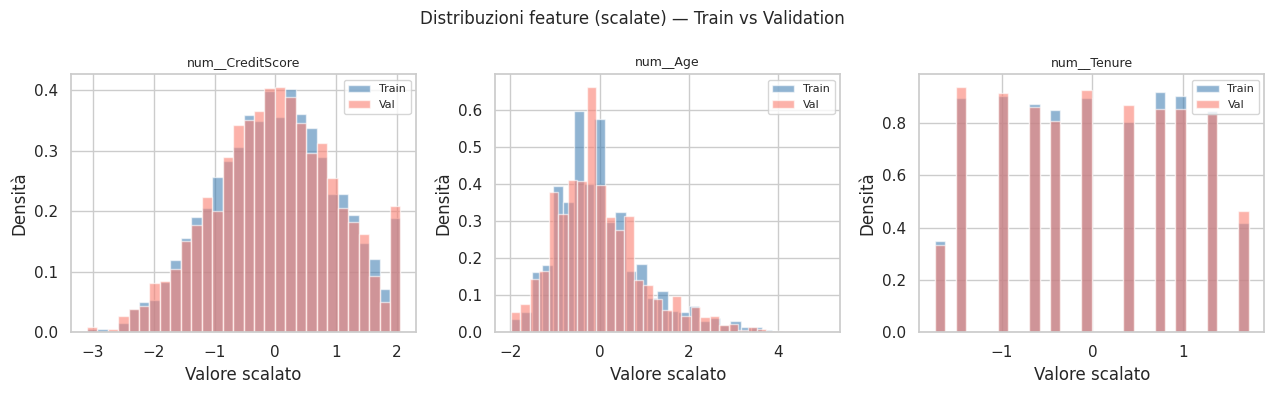

In [19]:
# Distribuzione di alcune feature numeriche: train vs val (dopo scaling)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
demo_indices = [0, 1, 2]  # prime 3 feature numeriche

for ax, idx in zip(axes, demo_indices):
    feat_name = feature_names_out[idx]
    ax.hist(
        X_train_proc[:, idx],
        bins=30,
        alpha=0.6,
        label="Train",
        color="steelblue",
        density=True,
    )
    ax.hist(
        X_val_proc[:, idx],
        bins=30,
        alpha=0.6,
        label="Val",
        color="salmon",
        density=True,
    )
    ax.set_title(feat_name, fontsize=9)
    ax.set_xlabel("Valore scalato")
    ax.set_ylabel("Densità")
    ax.legend(fontsize=8)

fig.suptitle("Distribuzioni feature (scalate) — Train vs Validation", fontsize=12)
save_current_figure("lesson_02_train_val_distributions.png")
plt.show()

- **NaN: 0** in tutti e tre i dataset processati — il preprocessing è completo.
- **Shape:** coerente con le attese (6,000 / 2,000 / 2,000 × 19 feature).
- Le feature numeriche sul **train set** hanno media ≈ **0** e std ≈ **1**: lo
  `StandardScaler` ha funzionato correttamente.
- Sul **validation set** le medie e std sono leggermente diverse da 0/1: questo è
  **corretto e atteso** — conferma che lo scaler è stato fittato solo sul train,
  senza contaminare il validation.
- Le distribuzioni dei due istogrammi si sovrappongono largamente (stesso dataset
  campionato casualmente), con piccole differenze casuali dovute alla randomizzazione
  dello split.

## 15. Salvataggio dataset modellabile

Salviamo i dataset processati in formato **Parquet**: compatto, tipizzato e
facilmente leggibile da `pandas` nelle lezioni successive.

In [20]:
# Convertire in DataFrame con nomi colonne per leggibilità
X_train_df = pd.DataFrame(X_train_proc, columns=feature_names_out)
X_val_df = pd.DataFrame(X_val_proc, columns=feature_names_out)
X_test_df = pd.DataFrame(X_test_proc, columns=feature_names_out)

y_train_df = y_train.reset_index(drop=True)
y_val_df = y_val.reset_index(drop=True)
y_test_df = y_test.reset_index(drop=True)

# Salvataggio
artifacts = {
    "lesson_02_X_train.parquet": X_train_df,
    "lesson_02_X_val.parquet": X_val_df,
    "lesson_02_X_test.parquet": X_test_df,
    "lesson_02_y_train.parquet": y_train_df.to_frame(),
    "lesson_02_y_val.parquet": y_val_df.to_frame(),
    "lesson_02_y_test.parquet": y_test_df.to_frame(),
}

for fname, df_out in artifacts.items():
    path = DATA_OUT_DIR / fname
    df_out.to_parquet(path, index=False)
    print(f"Salvato: {path}  (shape: {df_out.shape})")

# Salvataggio feature names come JSON
feature_names_path = DATA_OUT_DIR / "lesson_02_feature_names.json"
with open(feature_names_path, "w", encoding="utf-8") as fh:
    json.dump(feature_names_out, fh, indent=2)
print(f"\nFeature names salvati in: {feature_names_path}")

Salvato: /home/psoglia/desktop/machine-learning-lab-2026/outputs/data/lesson_02_X_train.parquet  (shape: (6000, 20))
Salvato: /home/psoglia/desktop/machine-learning-lab-2026/outputs/data/lesson_02_X_val.parquet  (shape: (2000, 20))
Salvato: /home/psoglia/desktop/machine-learning-lab-2026/outputs/data/lesson_02_X_test.parquet  (shape: (2000, 20))
Salvato: /home/psoglia/desktop/machine-learning-lab-2026/outputs/data/lesson_02_y_train.parquet  (shape: (6000, 1))
Salvato: /home/psoglia/desktop/machine-learning-lab-2026/outputs/data/lesson_02_y_val.parquet  (shape: (2000, 1))
Salvato: /home/psoglia/desktop/machine-learning-lab-2026/outputs/data/lesson_02_y_test.parquet  (shape: (2000, 1))

Feature names salvati in: /home/psoglia/desktop/machine-learning-lab-2026/outputs/data/lesson_02_feature_names.json


- I **6 dataset** (X e y per train/val/test) sono salvati in `outputs/data/` in
  formato Parquet.
- La **pipeline di preprocessing** è salvata in `outputs/data/lesson_02_preprocessor.pkl`.
- I **nomi delle feature** sono salvati in `outputs/data/lesson_02_feature_names.json`.
- In Lezione 3 basterà caricare questi file con `pd.read_parquet` e `joblib.load`
  per iniziare immediatamente a costruire e confrontare modelli.

## 16. Domande guidate

**1. Perché un modello con accuracy del 79.62% non è necessariamente buono
per il nostro problema?**

Un `DummyClassifier` che predice sempre "non churn" (y=0) ottiene accuracy =
**79.62%** semplicemente riflettendo la proporzione della classe maggioritaria.
Il suo recall sulla classe churn è **0%**: non identifica un solo churner.
Per problemi di churn, la metrica rilevante è il **recall** (quanti churner
reali identifichiamo) o la **ROC-AUC** (capacità discriminativa). In Lezione 1
il modello baseline con recall=21.1% era già migliore del "dummy" nonostante
una accuracy non lontana.

---

**2. Perché il fit dello scaler deve avvenire solo su `X_train` e non su
tutto il dataset?**

Se fittassimo lo scaler sull'intero dataset (train + val + test), la media e
la deviazione standard dello scaler sarebbero calcolate anche sui dati di
validation e test. In questo modo il preprocessing "vedrebbe" dati che il
modello non ha ancoraosservato durante il training, creando un **data leakage
implicito**. Le performance stimate sul validation/test sarebbero leggermente
ottimistiche e non rappresentative della performance su dati davvero nuovi.
Come verificato nella sezione 14, su `X_val` la media e la std **non** sono
esattamente 0 e 1: questo è il segnale corretto che lo scaler è stato fittato
solo su train.

---

**3. Qual è la differenza tra `class_weight="balanced"` e SMOTE?
Quando preferiresti l'uno o l'altro?**

`class_weight="balanced"` modifica la **funzione di loss** del modello,
assegnando peso **~2.45x** maggiore agli errori sulla classe minoritaria
(churn) durante il training. Non crea nuovi campioni. SMOTE invece crea
**campioni sintetici** interpolando tra esempi reali della classe minoritaria,
aumentando fisicamente il dataset. `class_weight="balanced"` è più semplice,
non rischioso e applicabile a qualsiasi modello sklearn che lo supporta.
SMOTE è preferibile quando il dataset è molto piccolo o lo sbilanciamento
molto severo (es. 1:100). In entrambi i casi, SMOTE va applicato **solo dopo
lo split**, mai prima.

---

**4. Perché abbiamo creato la feature `balance_is_zero` invece di usare
`Balance` direttamente?**

Il churn rate dei clienti con `Balance==0` (**13.82%**) è significativamente
diverso da quello con `Balance>0` (**24.10%**). Questa discontinuità non può
essere catturata da una trasformazione lineare del valore di `Balance`: un
modello lineare tratterà `Balance=0` e `Balance=1` come quasi uguali.
La feature binaria `balance_is_zero` permette al modello di apprendere
esplicitamente questa soglia senza richiedere termini di interazione complessi.
`Balance` originale viene comunque mantenuta per preservare l'informazione
sulla grandezza del saldo.

---

**5. Che differenza c'è tra validation set e test set? Quando usi l'uno
e quando l'altro?**

Il **validation set** viene usato durante lo sviluppo del modello: per scegliere
iperparametri, confrontare architetture diverse, e decidere la soglia di
classificazione ottimale. Viene "consumato" ogni volta che consultiamo i suoi
risultati per prendere una decisione. Il **test set** è una stima finale della
performance su dati "mai visti": deve essere usato **una sola volta**, alla fine,
per riportare il risultato definitivo. Usare il test set durante il tuning
introdurrebbe un **selection bias**: il modello sarebbe implicitamente ottimizzato
anche per il test, rendendo la stima di performance ottimistica.

## 17. Riepilogo

### Operazioni completate e artefatti prodotti

| Operazione | Risultato |
|-----------|-----------|
| Rimozione variabili non predittive e leakage | `df_clean`: 14 colonne (−4 da df originale) |
| Analisi imbalance e metriche | Churn = 20.38%; accuracy da sola è fuorviante |
| Strategie sbilanciamento | 5 strategie presentate; `class_weight` e SMOTE dimostrate |
| Outlier check (IQR) | Outlier contenuti (<1%); nessun clipping necessario |
| Feature engineering | `balance_is_zero`: churn rate 13.82% (saldo zero) vs 24.10% (saldo positivo) |
| Split 60/20/20 stratificato | Train: 6,000 \| Val: 2,000 \| Test: 2,000 — churn rate costante (~20.38%) |
| OneHotEncoding (fit su train) | 3 feature categoriche → 9 colonne dummy |
| StandardScaler (fit su train) | 10 feature numeriche normalizzate (media≈0, std≈1 su train) |
| Pipeline ColumnTransformer | 13 feature input → 19 feature output |
| Verifica preprocessing | NaN: 0; shape corretti; no leakage confermato |
| Salvataggio dataset modellabile | 6 file Parquet + pipeline PKL + feature names JSON |

### Confronto con la Lezione 1

| Aspetto | Lezione 1 | Lezione 2 |
|---------|-----------|-----------|
| Feature set | 14 colonne (con dummy one-hot rapido) | 13 feature → 19 dopo Pipeline |
| Preprocessing | Minimale (imputer + scaler + get_dummies su tutto il dataset) | Pipeline completa, anti-leakage |
| Split | 80/20 (senza validation set) | 60/20/20 stratificato |
| Dataset modellabile | Solo in memoria | Persistito in `outputs/data/` |

### Prossima lezione (Lezione 3)

Nella **Lezione 3** utilizzeremo il dataset modellabile salvato per:
- Costruire e confrontare modelli di classificazione: Logistic Regression,
  Decision Tree, Random Forest.
- Calcolare e interpretare le metriche: Accuracy, Precision, Recall, F1, ROC-AUC.
- Visualizzare la Confusion Matrix e la ROC Curve.
- Discutere il trade-off Precision–Recall nel contesto del churn bancario.